In [5]:
!pip install -q opencv-contrib-python


In [6]:
import os, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt

raw_dir = "/content/data/raw"
out_dir = "/content/data/preprocessed"
os.makedirs(out_dir, exist_ok=True)


In [7]:
def clahe_lab(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

def retinex(img, sigma=80):
    img = img.astype(np.float32) + 1.0
    blur = cv2.GaussianBlur(img, (0,0), sigma)
    out = np.log(img) - np.log(blur)
    out = cv2.normalize(out, None, 0, 255, cv2.NORM_MINMAX)
    return out.astype(np.uint8)

def photometric(img):
    a = clahe_lab(img)
    r = retinex(a)
    return r


In [8]:
def warp(img, src_pts, size=(512,512)):
    w, h = size
    dst_pts = np.float32([[0,0],[w-1,0],[w-1,h-1],[0,h-1]])
    H = cv2.getPerspectiveTransform(np.float32(src_pts), dst_pts)
    return cv2.warpPerspective(img, H, (w,h))


In [10]:
def geometric(img, size=(512,512)):
    th, tw = size
    h, w = img.shape[:2]
    s = min(tw/w, th/h)
    nw, nh = int(w*s), int(h*s)
    r = cv2.resize(img, (nw,nh))
    c = np.zeros((th,tw,3), dtype=r.dtype)
    y = (th-nh)//2
    x = (tw-nw)//2
    c[y:y+nh, x:x+nw] = r
    return c


In [11]:
def denoise(img):
    return cv2.bilateralFilter(img, 7, 75, 75)

def highpass(img):
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    b = cv2.GaussianBlur(g, (0,0), 9)
    h = cv2.addWeighted(g, 1.5, b, -0.5, 0)
    h = cv2.normalize(h, None, 0, 255, cv2.NORM_MINMAX)
    return h


In [12]:
def preprocess(img, src_pts, size=(512,512)):
    p = photometric(img)
    v = warp(p, src_pts, size)
    g = geometric(v, size)
    d = denoise(g)
    h = highpass(d)
    return g, h


In [13]:
def list_images(folder):
    out = []
    for e in ["*.png","*.jpg","*.jpeg","*.bmp","*.tif"]:
        out.extend(glob.glob(os.path.join(folder, e)))
    return sorted(out)

src_pts = [[50,50],[350,50],[350,350],[50,350]]
dst_size = (512,512)

imgs = list_images(raw_dir)
for f in imgs:
    img = cv2.imread(f)
    geo, enh = preprocess(img, src_pts, dst_size)
    b = os.path.splitext(os.path.basename(f))[0]
    cv2.imwrite(os.path.join(out_dir, b+"_norm.png"), geo)
    cv2.imwrite(os.path.join(out_dir, b+"_enh.png"), enh)


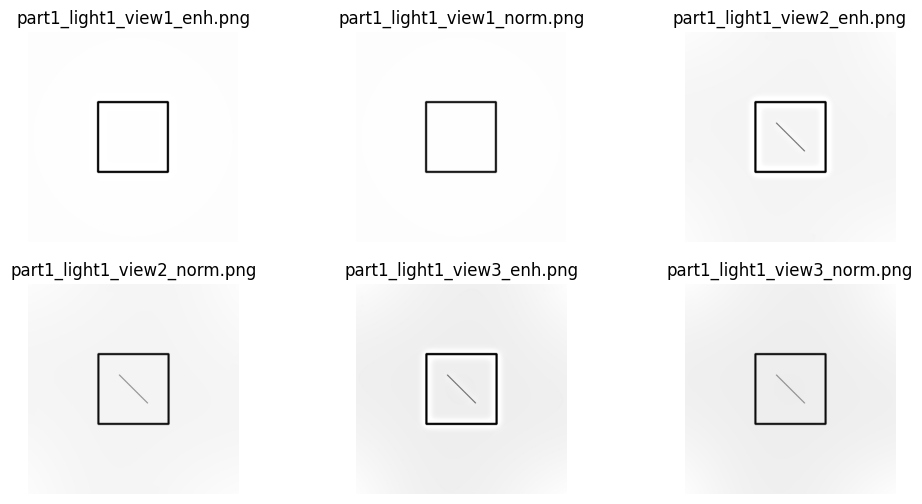

In [14]:
files = list_images(out_dir)
plt.figure(figsize=(12,6))
for i,f in enumerate(files[:6]):
    img = cv2.imread(f)
    if img.ndim==2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(os.path.basename(f))
    plt.axis("off")
plt.show()
